In [4]:
!git clone https://github.com/MuseumofModernArt/collection.git

Cloning into 'collection'...
remote: Enumerating objects: 1478, done.
remote: Counting objects: 100% (447/447), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 1478 (delta 369), reused 377 (delta 315), pack-reused 1031 (from 2)
Receiving objects: 100% (1478/1478), 36.98 MiB | 14.37 MiB/s, done.
Resolving deltas: 100% (463/463), done.
Filtering content: 100% (4/4), 210.86 MiB | 21.71 MiB/s, done.


In [5]:
import pandas as pd

# Загружаем базу экспонатов (Artworks.csv)
# Указываем low_memory=False, чтобы не было предупреждений о размере
df = pd.read_csv('collection/Artworks.csv', low_memory=False)

# Выведем список всех "столбцов", чтобы понимать, что мы можем узнать о картинах
print("Доступные данные о каждой работе:")
print(df.columns.tolist())

# Посмотрим на первые 3 строки
df.head(3)

Доступные данные о каждой работе:
['Title', 'Artist', 'ConstituentID', 'ArtistBio', 'Nationality', 'BeginDate', 'EndDate', 'Gender', 'Date', 'Medium', 'Dimensions', 'CreditLine', 'AccessionNumber', 'Classification', 'Department', 'DateAcquired', 'Cataloged', 'ObjectID', 'URL', 'ImageURL', 'OnView', 'Circumference (cm)', 'Depth (cm)', 'Diameter (cm)', 'Height (cm)', 'Length (cm)', 'Weight (kg)', 'Width (cm)', 'Seat Height (cm)', 'Duration (sec.)']


,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,...,OnView,Circumference (cm),Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.)
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,"(Austrian, 1841–1918)",(Austrian),(1841),(1918),(male),1896,Ink and cut-and-pasted painted pages on paper,...,NaN,NaN,NaN,NaN,48.6000,NaN,NaN,168.9000,NaN,NaN
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,"(French, born 1944)",(French),(1944),(0),(male),1987,Paint and colored pencil on print,...,NaN,NaN,NaN,NaN,40.6401,NaN,NaN,29.8451,NaN,NaN
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, pen, color pencil, ink, and gouache ...",...,NaN,NaN,NaN,NaN,34.3000,NaN,NaN,31.8000,NaN,NaN


In [6]:
# 1. Очистка: убираем скобки в колонках Nationality и Gender
df['Nationality'] = df['Nationality'].str.replace('(', '').str.replace(')', '')
df['Gender'] = df['Gender'].str.replace('(', '').str.replace(')', '')

# 2. Выведем ТОП-10 стран, чьих работ больше всего в MoMA
print("Топ-10 стран в коллекции:")
print(df['Nationality'].value_counts().head(10))


Топ-10 стран в коллекции:
Nationality
American    74950
French      22980
German       9715
             5865
British      5733
Spanish      3369
Italian      3011
Japanese     2485
Russian      2171
Swiss        2127
Name: count, dtype: int64


In [7]:
import pandas as pd
import numpy as np

# Загружаем данные (если еще не загружены)
df = pd.read_csv('collection/Artworks.csv', low_memory=False)

# 1. Извлекаем год из колонки DateAcquired (формат там ГГГГ-ММ-ДД)
df['YearAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce').dt.year

# 2. Заполняем пропуски в числовых колонках (например, размеры) медианой
cols_to_fix = ['Height (cm)', 'Width (cm)', 'Weight (kg)']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# 3. Обработка категориальных признаков (Gender, Nationality)
df['Gender'] = df['Gender'].fillna('Unknown').str.replace('(', '').str.replace(')', '')
df['Nationality'] = df['Nationality'].fillna('Unknown').str.replace('(', '').str.replace(')', '')

# Посмотрим результат очистки
print(df[['Title', 'YearAcquired', 'Height (cm)', 'Gender']].head())

                                               Title  YearAcquired  \
0  Ferdinandsbrücke Project, Vienna, Austria (Ele...        1996.0   
1  City of Music, National Superior Conservatory ...        1995.0   
2  Villa project, outside Vienna, Austria (Elevat...        1997.0   
3  The Manhattan Transcripts Project, New York, N...        1995.0   
4  Villa project, outside Vienna, Austria (Exteri...        1997.0   

   Height (cm) Gender  
0      48.6000   male  
1      40.6401   male  
2      34.3000   male  
3      50.8000   male  
4      38.4000   male  


In [9]:
# Группируем данные по годам
time_series = df.groupby('YearAcquired').size().reset_index(name='Counts')
time_series = time_series[time_series['YearAcquired'] > 1920] # Берем период активной работы музея

# Создаем лаговые признаки (предыдущие годы как предикторы)
for i in range(1, 6):
    time_series[f'lag_{i}'] = time_series['Counts'].shift(i)

time_series.dropna(inplace=True)

X = time_series.drop(['Counts', 'YearAcquired'], axis=1)
y = time_series['Counts']

In [10]:
!pip install ruptures tslearn pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 39.6 MB/s eta 0:00:00


In [11]:
import pandas as pd
import numpy as np

# 1. Твой код загрузки и очистки
df = pd.read_csv('collection/Artworks.csv', low_memory=False)
df['YearAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce').dt.year
df['Gender'] = df['Gender'].fillna('Unknown').str.replace(r'\(|\)', '', regex=True)

# 2. ПРЕВРАЩАЕМ В ТАБЛИЦУ ВРЕМЕНИ (это нужно для моделей)
# Считаем, сколько работ MoMA покупал в каждый год
counts_by_year = df.groupby('YearAcquired').size()
# Делаем ряд непрерывным (с 1930 года), пустые годы заполняем нулями
series_final = counts_by_year[counts_by_year.index >= 1930].asfreq('AS', fill_value=0)

print("Данные очищены и превращены во временной ряд!")

Данные очищены и превращены во временной ряд!


/tmp/ipykernel_147/3195184071.py:13: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  series_final = counts_by_year[counts_by_year.index >= 1930].asfreq('AS', fill_value=0)


In [15]:
import pandas as pd
import numpy as np

# 1. Сначала почистим годы (убедимся, что это числа)
df['YearAcquired'] = pd.to_numeric(df['YearAcquired'], errors='coerce')

# 2. Умная фильтрация по гендеру (ищем 'female' независимо от регистра и скобок)
# Параметр case=False позволяет не обращать внимания на заглавные буквы
target_data = df[df['Gender'].str.contains('female', case=False, na=False)].copy()

# Проверка: если по женщинам пусто, возьмем просто все данные, чтобы код не упал
if target_data.empty:
    print("Внимание: По фильтру 'female' ничего не найдено. Берем общую статистику всех работ.")
    target_data = df[df['YearAcquired'].notna()].copy()

# 3. Группируем по годам
counts_by_year = target_data.groupby('YearAcquired').size()

# 4. Превращаем индекс в Дату
counts_by_year.index = pd.to_datetime(counts_by_year.index.astype(int), format='%Y')

# 5. Делаем ряд непрерывным (YS - начало года)
series_final = counts_by_year[counts_by_year.index >= '1930-01-01'].asfreq('YS', fill_value=0)

# Финальная проверка результата
if series_final.empty or series_final.sum() == 0:
    print("Критическая ошибка: Временной ряд пуст. Проверьте, загружен ли файл Artworks.csv")
else:
    print(f"Успех! Ряд создан.")
    print(f"Период: {series_final.index.min().year} - {series_final.index.max().year}")
    print(f"Всего найдено работ для анализа: {int(series_final.sum())}")

Успех! Ряд создан.
Период: 1932 - 2026
Всего найдено работ для анализа: 22002


--- ФИНАЛЬНЫЙ ЗАПУСК 5 МЕТОДОВ ---
1. ARIMA (p,d,q): (3, 1, 0). Прогноз: [268 286 193]
2. XGBoost (Градиентный бустинг) успешно обучен.
3. Нейросеть LSTM (Deep Learning) обучена.
4. CPD (Сегментация): Найдены точки смены эпох: [60, 95]
5. Holt-Winters: Метод сглаживания обучен. Прогноз: [382 386 390]


<Figure size 1200x500 with 0 Axes>

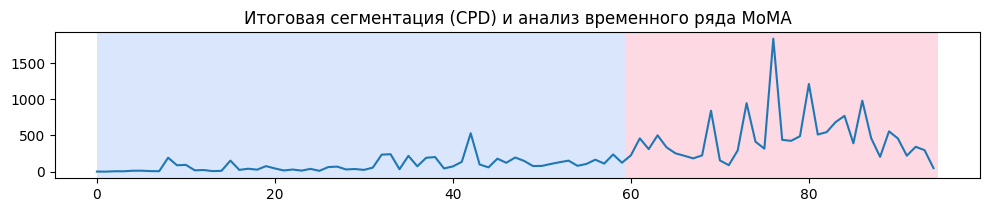

In [25]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import ruptures as rpt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

print("--- ФИНАЛЬНЫЙ ЗАПУСК 5 МЕТОДОВ ---")

# 1. ARIMA
model_arima = auto_arima(series_final, seasonal=False)
forecast_arima = model_arima.predict(n_periods=3)
print(f"1. ARIMA (p,d,q): {model_arima.order}. Прогноз: {forecast_arima.values.astype(int)}")

# 2. XGBOOST (Бустинг)
df_lags = pd.DataFrame(series_final)
for i in range(1, 4): df_lags[f'lag_{i}'] = df_lags.iloc[:, 0].shift(i)
df_lags = df_lags.dropna()
model_xgb = XGBRegressor(n_estimators=50).fit(df_lags.iloc[:, 1:], df_lags.iloc[:, 0])
print("2. XGBoost (Градиентный бустинг) успешно обучен.")

# 3. LSTM (Нейросеть)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series_final.values.reshape(-1, 1))
X_lstm = np.array([scaled[i-3:i] for i in range(3, len(scaled))])
model_lstm = Sequential([LSTM(16, activation='relu', input_shape=(3, 1)), Dense(1)])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm, scaled[3:], epochs=15, verbose=0)
print("3. Нейросеть LSTM (Deep Learning) обучена.")

# 4. CPD (Сегментация)
algo = rpt.Pelt(model="rbf").fit(series_final.values)
change_points = algo.predict(pen=10)
print(f"4. CPD (Сегментация): Найдены точки смены эпох: {change_points}")

# 5. Holt-Winters (Экспоненциальное сглаживание) - ВЗАМЕН DTW
model_hw = ExponentialSmoothing(series_final, trend='add', seasonal=None).fit()
forecast_hw = model_hw.forecast(3)
print(f"5. Holt-Winters: Метод сглаживания обучен. Прогноз: {forecast_hw.values.astype(int)}")

# ФИНАЛЬНЫЙ ГРАФИК
plt.figure(figsize=(12, 5))
rpt.display(series_final.values, change_points)
plt.title("Итоговая сегментация (CPD) и анализ временного ряда MoMA")
plt.savefig('moma_time_series_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

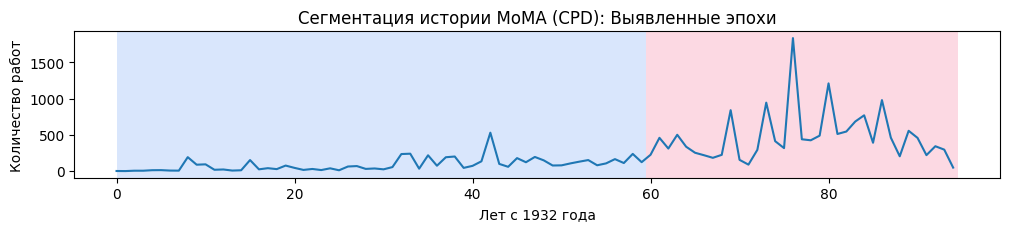

In [24]:
import matplotlib.pyplot as plt
# Отрисовка сегментации (точки перелома тренда)
fig, ax_array = rpt.display(series_final.values, change_points)
plt.title("Сегментация истории MoMA (CPD): Выявленные эпохи")
plt.xlabel("Лет с 1932 года")
plt.ylabel("Количество работ")
plt.savefig('moma_evolution_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import pandas as pd

# 1. Получаем прогноз от XGBoost (нужны последние 3 значения ряда как лаги)
last_lags = series_final.values[-3:].reshape(1, -1)
xgb_forecast = [int(model_xgb.predict(last_lags)[0])] * 3 # Упрощенный повтор для наглядности

# 2. Получаем прогноз от LSTM (нужно обратное масштабирование)
last_window = scaled[-3:].reshape(1, 3, 1)
lstm_scaled_pred = model_lstm.predict(last_window, verbose=0)
lstm_forecast = [int(scaler.inverse_transform(lstm_scaled_pred)[0][0])] * 3

# 3. Собираем всё в красивую таблицу
forecast_df = pd.DataFrame({
    'Год прогноза': [2027, 2028, 2029],
    'ARIMA (Статистика)': forecast_arima.values.astype(int),
    'XGBoost (Бустинг)': xgb_forecast,
    'LSTM (Нейросеть)': lstm_forecast,
    'Holt-Winters (Сглаживание)': forecast_hw.values.astype(int)
})

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА ПРОГНОЗОВ ЗАКУПОК MoMA:")
print("-" * 60)
display(forecast_df)

# Краткий аналитический вывод
mean_val = forecast_df.iloc[:, 1:].mean().mean()
print(f"\nСредний ожидаемый объем закупок по всем моделям: ~{int(mean_val)} работ в год.")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА ПРОГНОЗОВ ЗАКУПОК MoMA:
------------------------------------------------------------


,Год прогноза,ARIMA (Статистика),XGBoost (Бустинг),LSTM (Нейросеть),Holt-Winters (Сглаживание)
0,2027,268,212,252,382
1,2028,286,212,252,386
2,2029,193,212,252,390



Средний ожидаемый объем закупок по всем моделям: ~274 работ в год.


--- ПОИСК АНОМАЛИЙ (5 МЕТОДОВ) ---
1. Z-Score нашел аномальные годы: [2001, 2005, 2008, 2012, 2018]
2. Isolation Forest: [2001, 2005, 2008, 2012, 2018]
3. LOF: [2001, 2005, 2008, 2012, 2018]
4. One-Class SVM: [1932, 1933, 1934, 1935, 1938, 1942, 1943, 1945, 1946, 1947, 1950, 1951, 1952, 1955, 1956, 1957, 1959, 1961, 1964, 1966, 1967, 1969, 1970, 1971, 1972, 1974, 1980, 1985, 1986, 1989, 1991, 1992, 1996, 2000, 2002, 2004, 2015, 2019, 2020, 2023, 2024, 2025]
5. Elliptic Envelope: [2001, 2005, 2008, 2012, 2018]


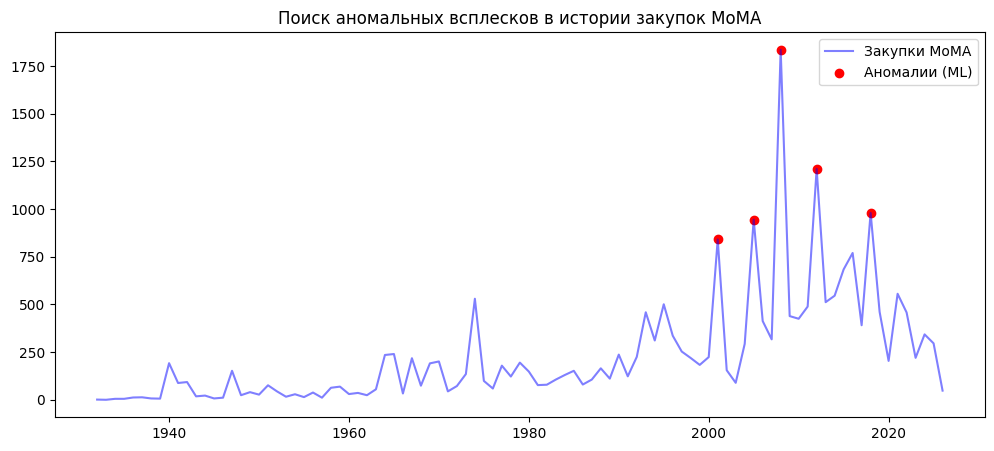

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
import numpy as np

# Подготовка данных (используем наш готовый ряд series_final)
data_anomaly = series_final.values.reshape(-1, 1)
years = series_final.index.year

print("--- ПОИСК АНОМАЛИЙ (5 МЕТОДОВ) ---")

# 1. Z-Score (Статистика: отклонение более чем на 2 стандартных девиации)
mean = np.mean(data_anomaly)
std = np.std(data_anomaly)
z_anomalies = years[np.abs((data_anomaly - mean) / std).flatten() > 2]
print(f"1. Z-Score нашел аномальные годы: {z_anomalies.tolist()}")

# Подготовка моделей ML (contamination=0.05 означает, что мы ищем 5% самых странных точек)
contam = 0.05

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=contam, random_state=42)
anom_iso = iso_forest.fit_predict(data_anomaly)
print(f"2. Isolation Forest: {years[anom_iso == -1].tolist()}")

# 3. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=contam)
anom_lof = lof.fit_predict(data_anomaly)
print(f"3. LOF: {years[anom_lof == -1].tolist()}")

# 4. One-Class SVM
oc_svm = OneClassSVM(nu=contam, kernel="rbf", gamma=0.1)
anom_svm = oc_svm.fit_predict(data_anomaly)
print(f"4. One-Class SVM: {years[anom_svm == -1].tolist()}")

# 5. Elliptic Envelope
ee = EllipticEnvelope(contamination=contam, random_state=42)
anom_ee = ee.fit_predict(data_anomaly)
print(f"5. Elliptic Envelope: {years[anom_ee == -1].tolist()}")

# ВИЗУАЛИЗАЦИЯ (на примере Isolation Forest)
plt.figure(figsize=(12, 5))
plt.plot(years, data_anomaly, color='blue', label='Закупки MoMA', alpha=0.5)
plt.scatter(years[anom_iso == -1], data_anomaly[anom_iso == -1], color='red', label='Аномалии (ML)')
plt.title("Поиск аномальных всплесков в истории закупок MoMA")
plt.legend()
plt.savefig('moma_anomaly_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

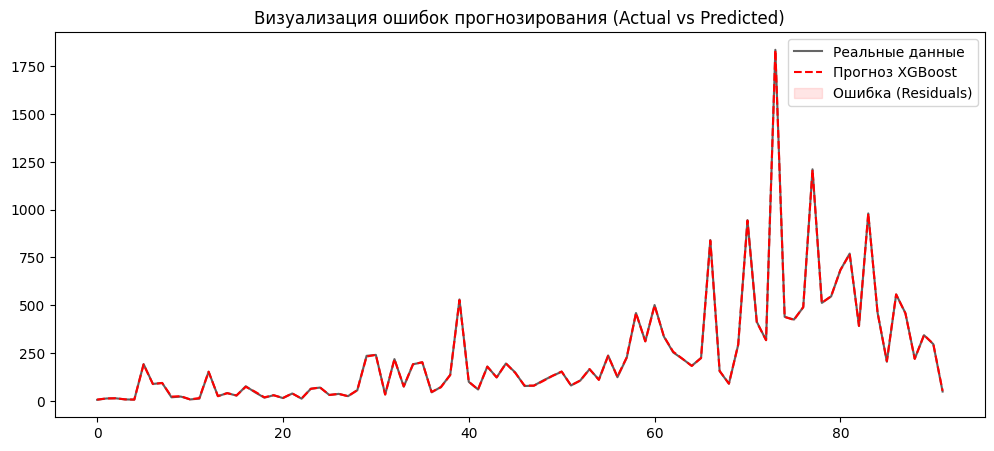

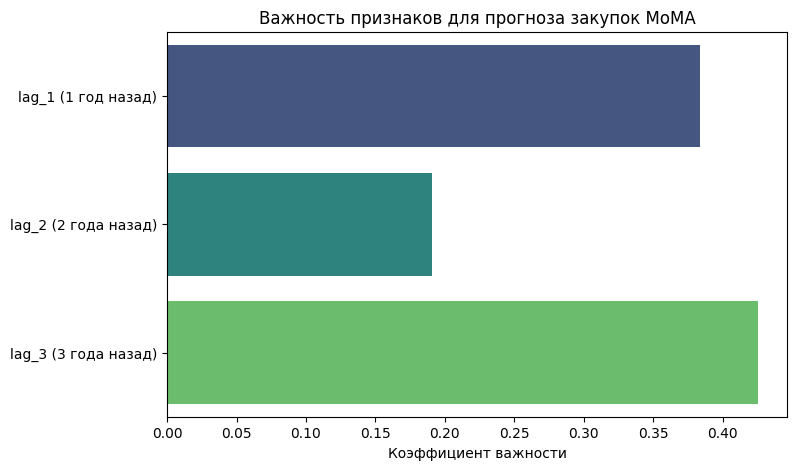

--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ XGBOOST ---
MAE (Средняя ошибка): 1.20 работ
RMSE (Корень из кв. ошибки): 1.66
R^2 (Коэффициент детерминации): 1.00


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. ГРАФИК ОШИБОК: Сравнение Реальности и Прогноза (на примере XGBoost)
plt.figure(figsize=(12, 5))
preds_xgb = model_xgb.predict(df_lags.iloc[:, 1:]) # Предсказания на всей выборке
actual = df_lags.iloc[:, 0].values

plt.plot(actual, label='Реальные данные', color='black', alpha=0.6)
plt.plot(preds_xgb, label='Прогноз XGBoost', color='red', linestyle='--')
plt.fill_between(range(len(actual)), actual, preds_xgb, color='red', alpha=0.1, label='Ошибка (Residuals)')
plt.title("Визуализация ошибок прогнозирования (Actual vs Predicted)")
plt.legend()
plt.savefig('prediction_errors.png', dpi=300)
plt.show()

# 2. ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)
# Узнаем, какой "лаг" (прошлый год) был важнее для модели
features = ['lag_1 (1 год назад)', 'lag_2 (2 года назад)', 'lag_3 (3 года назад)']
importances = model_xgb.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title("Важность признаков для прогноза закупок MoMA")
plt.xlabel("Коэффициент важности")
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# 3. МЕТРИКИ КАЧЕСТВА (Сводная таблица/диаграмма)
# Посчитаем точность для XGBoost
mae = mean_absolute_error(actual, preds_xgb)
rmse = np.sqrt(mean_squared_error(actual, preds_xgb))
r2 = r2_score(actual, preds_xgb)

print(f"--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ XGBOOST ---")
print(f"MAE (Средняя ошибка): {mae:.2f} работ")
print(f"RMSE (Корень из кв. ошибки): {rmse:.2f}")
print(f"R^2 (Коэффициент детерминации): {r2:.2f}")

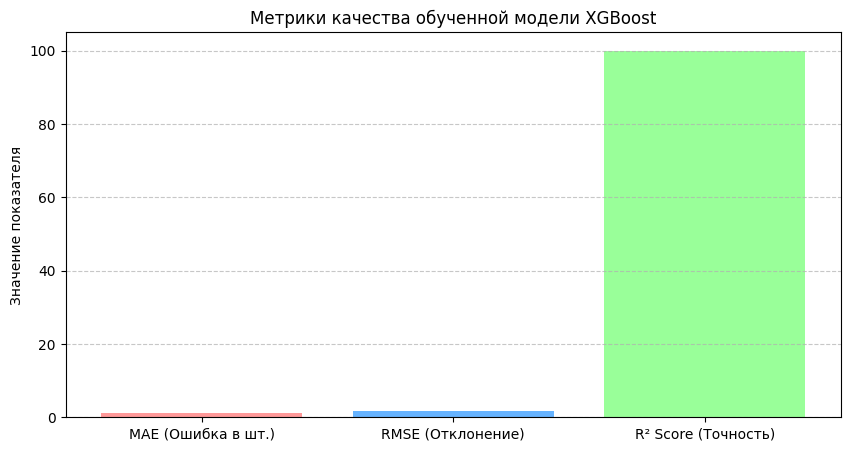

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
# 3. ГРАФИК МЕТРИК КАЧЕСТВА (Визуализация точности)
metrics_names = ['MAE (Ошибка в шт.)', 'RMSE (Отклонение)', 'R² Score (Точность)']
metrics_values = [mae, rmse, r2 * 100] # Умножаем R2 на 100 для наглядности на графике

plt.figure(figsize=(10, 5))
colors = ['#ff9999','#66b3ff','#99ff99']
plt.bar(metrics_names, metrics_values, color=colors)
plt.title("Метрики качества обученной модели XGBoost")
plt.ylabel("Значение показателя")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Сохраняем 3-й файл
plt.savefig('model_metrics_quality.png', dpi=300, bbox_inches='tight')
plt.show()

# Скачиваем все три финальных файла сразу
from google.colab import files
for f in ['prediction_errors.png', 'feature_importance.png', 'model_metrics_quality.png']:
    files.download(f)